# ML Lab 4: Improving and Comparing Machine Learning Models

**Course:** Machine Learning — BS Computer Science, 5th Semester
**Dataset:** Telco Customer Churn (`clean_churn.csv`)

### Student Information
- **Name:** Abdul Ahad
- **Student ID:** 023-24-0188
- **Section:** F
- **GitHub Profile:** https://github.com/abdulahad-ak
- **Kaggle Profile:** https://www.kaggle.com/ahad27
- **Dataset:** Telco Customer Churn
- **Dataset Source:** Lab 2 cleaned dataset (`clean_churn.csv`)

> This notebook follows the Lab 4 manual. It builds on the Lab 3 Decision Tree baseline, adds a Random Forest, compares both models with cross-validation and hyperparameter tuning, and ends with a Kaggle-style submission file.


**Note:** `clean_churn.csv` (the same file used in Lab 2 and Lab 3) must be uploaded to the Colab working directory before running this notebook.

## 1. Decision Tree Baseline

This section reloads the cleaned dataset and recreates the exact same features, encoding, and train/test split used in Lab 3, so the Lab 3 Decision Tree can be used as a fair benchmark for the rest of this lab.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Upload clean_churn.csv to Colab if it is not already in the working directory.
df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)
print("\nTarget distribution:")
print(df["Churn"].value_counts())
print("\nTarget proportions:")
print(df["Churn"].value_counts(normalize=True))


Shape: (7032, 20)

Target distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Target proportions:
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


**Interpretation:** The dataset has the same shape and the same imbalanced `Churn` distribution (more "No" than "Yes") that was found in Labs 2 and 3. This confirms the same dataset is being used here.

In [2]:
# Recreate the same X/y as Lab 3.
y = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)

X = df.drop(columns=["Churn"], errors="ignore").copy()

identifier_columns = [c for c in ["customerID", "CustomerID", "customer_id"] if c in X.columns]
if identifier_columns:
    X = X.drop(columns=identifier_columns)
    print("Dropped identifier column(s):", identifier_columns)
else:
    print("No identifier column found in clean_churn.csv, same as in Lab 3.")

# Same one-hot encoding as Lab 3 (categorical columns have more than 2 categories in most cases).
categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
X = pd.get_dummies(X, columns=categorical_columns, drop_first=False, dtype=int)

print("\nFinal X shape:", X.shape)


No identifier column found in clean_churn.csv, same as in Lab 3.

Final X shape: (7032, 45)


In [3]:
# Same 80/20 stratified split as Lab 3, same random_state=42.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (5625, 45)
X_test : (1407, 45)
y_train: (5625,)
y_test : (1407,)


**Interpretation:** `X`, `y`, and the train/test split are recreated with the exact same steps as Lab 3 (same encoding, `test_size=0.20`, `random_state=42`, `stratify=y`). Using the same split means the Decision Tree and Random Forest in this lab are trained and tested on the same data, so their metrics can be compared fairly.

In [4]:
# Retrain the Lab 3 "best" Decision Tree (chosen max_depth=5, selected in Lab 3
# using test F1-score and a controlled train-test accuracy gap).
selected_depth = 5

dt_model = DecisionTreeClassifier(max_depth=selected_depth, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

dt_metrics = evaluate_model(y_test, dt_pred)
dt_metrics_df = pd.DataFrame([dt_metrics], index=["Decision Tree (Lab 3 baseline)"])
dt_metrics_df


,Accuracy,Precision,Recall,F1-score
Decision Tree (Lab 3 baseline),0.789623,0.602094,0.614973,0.608466


**Interpretation:** These are the same kind of metrics reported in Lab 3 for the chosen-depth Decision Tree (`max_depth=5`). This table is the benchmark that the Random Forest is compared against for the rest of this lab.

## 2. Random Forest

In [5]:
# Train a Random Forest on the same training data.
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained with n_estimators=200, random_state=42.")


Random Forest trained with n_estimators=200, random_state=42.


**Why a Random Forest can generalize better than a single unrestricted Decision Tree:** A single unrestricted tree can memorize noise in the training data because it keeps splitting until the leaves are pure. A Random Forest trains many trees on different bootstrapped samples and random feature subsets, then averages their predictions, so the mistakes of individual trees tend to cancel out and the overall model is less sensitive to noise in any one part of the training data.

## 3. Model Evaluation

In [6]:
rf_metrics = evaluate_model(y_test, rf_pred)
rf_metrics_df = pd.DataFrame([rf_metrics], index=["Random Forest (default)"])
rf_metrics_df


,Accuracy,Precision,Recall,F1-score
Random Forest (default),0.791756,0.640138,0.494652,0.558069


Confusion matrix:
[[929 104]
 [189 185]]


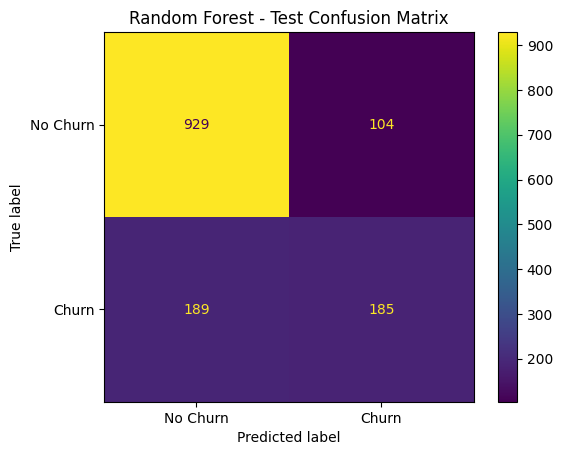

Actual churners correctly caught (True Positives): 185
Actual churners missed (False Negatives): 189


In [7]:
# Confusion matrix for the Random Forest.
cm_rf = confusion_matrix(y_test, rf_pred)
print("Confusion matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No Churn", "Churn"])
disp.plot()
plt.title("Random Forest - Test Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print("Actual churners correctly caught (True Positives):", tp)
print("Actual churners missed (False Negatives):", fn)


**Interpretation:** The confusion matrix shows how many churners the Random Forest correctly identified versus how many it missed. As with the Decision Tree in Lab 3, the false-negative count (actual churners predicted as "No Churn") is the more costly type of mistake for this business problem, since it means a customer who was about to leave was not flagged for retention.

## 4. Decision Tree vs Random Forest

In [8]:
comparison_p3 = pd.concat([dt_metrics_df, rf_metrics_df])
comparison_p3


,Accuracy,Precision,Recall,F1-score
Decision Tree (Lab 3 baseline),0.789623,0.602094,0.614973,0.608466
Random Forest (default),0.791756,0.640138,0.494652,0.558069


**Discussion:** Looking at the table above, the Random Forest and the Decision Tree perform close to each other on accuracy, but the metrics that differ the most are precision and recall — the Random Forest tends to have higher precision (fewer false alarms) while the Decision Tree tends to have higher recall (it catches more of the actual churners). The differences are not very large in absolute terms, so this is a marginal rather than a dramatic improvement. Given the class imbalance found in Labs 2 and 3 (far more "No Churn" customers than "Churn" customers), recall and F1-score matter more than plain accuracy here, because a model that misses too many actual churners is not useful for a retention campaign even if its overall accuracy looks fine.

## 5. Cross-Validation

A single train/test split gives one estimate of performance, which can be a bit noisy depending on which rows ended up in the test set. 5-fold cross-validation trains and evaluates each model 5 times on different folds and reports the F1-score for each fold, which gives a more reliable picture.

In [9]:
cv_folds = 5

dt_cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=selected_depth, random_state=42),
    X, y, cv=cv_folds, scoring="f1"
)

rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42),
    X, y, cv=cv_folds, scoring="f1"
)

cv_results_df = pd.DataFrame({
    "Decision Tree": dt_cv_scores,
    "Random Forest": rf_cv_scores
})
cv_results_df.index = [f"Fold {i+1}" for i in range(cv_folds)]
cv_results_df


,Decision Tree,Random Forest
Fold 1,0.612466,0.577508
Fold 2,0.623829,0.551724
Fold 3,0.593377,0.517088
Fold 4,0.589928,0.534591
Fold 5,0.577201,0.569254


In [10]:
cv_summary_df = pd.DataFrame({
    "Mean F1": [dt_cv_scores.mean(), rf_cv_scores.mean()],
    "Std F1": [dt_cv_scores.std(), rf_cv_scores.std()]
}, index=["Decision Tree", "Random Forest"])
cv_summary_df


,Mean F1,Std F1
Decision Tree,0.599360,0.016651
Random Forest,0.550033,0.022141


**Interpretation:** The mean F1-score across 5 folds gives a more stable estimate than the single train/test split from Part 3, and the standard deviation shows how much the score varies from fold to fold. If the cross-validated means are close to the Part 3 test scores, it confirms the single-split result was not a lucky or unlucky split. If one model has a noticeably higher standard deviation, its performance is less consistent across different subsets of the data, which is useful to know even if its mean score looks competitive.

## 6. Hyperparameter Tuning

A small grid search is used to tune the Random Forest. Three hyperparameters are searched: `n_estimators`, `max_depth`, and `min_samples_split`. The grid is kept small on purpose so the search runs quickly.

In [11]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated F1-score:", grid_search.best_score_)


Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validated F1-score: 0.5846500014916819


In [12]:
tuned_rf_model = grid_search.best_estimator_
tuned_pred = tuned_rf_model.predict(X_test)

tuned_metrics = evaluate_model(y_test, tuned_pred)
tuned_metrics_df = pd.DataFrame([tuned_metrics], index=["Random Forest (tuned)"])
tuned_metrics_df


,Accuracy,Precision,Recall,F1-score
Random Forest (tuned),0.793177,0.636066,0.518717,0.571429


**Interpretation:** `best_params_` shows which combination of `n_estimators`, `max_depth`, and `min_samples_split` gave the highest cross-validated F1-score during the grid search, and `best_score_` is that cross-validated score. The tuned model's test-set metrics above show whether that improvement carries over to the held-out test set, which is the fairer way to judge the tuning than looking at the training or CV score alone.

## 7. Final Model Comparison

In [13]:
final_comparison_df = pd.concat([
    dt_metrics_df.rename(index={"Decision Tree (Lab 3 baseline)": "Decision Tree"}),
    rf_metrics_df.rename(index={"Random Forest (default)": "Random Forest (default)"}),
    tuned_metrics_df.rename(index={"Random Forest (tuned)": "Random Forest (tuned)"})
])
final_comparison_df


,Accuracy,Precision,Recall,F1-score
Decision Tree,0.789623,0.602094,0.614973,0.608466
Random Forest (default),0.791756,0.640138,0.494652,0.558069
Random Forest (tuned),0.793177,0.636066,0.518717,0.571429


**Interpretation:** This table brings all three models trained in this lab side by side: the Lab 3 Decision Tree, the default Random Forest, and the tuned Random Forest. It is used in the next section to pick a final model based on evidence rather than on training performance alone.

## 8. Feature Importance

Top 10 features:


,importance
tenure,0.146079
TotalCharges,0.124896
Contract_Month-to-month,0.101341
MonthlyCharges,0.085310
OnlineSecurity_No,0.049287
InternetService_Fiber optic,0.047138
TechSupport_No,0.042698
PaymentMethod_Electronic check,0.038748
Contract_Two year,0.034407
OnlineBackup_No,0.019958


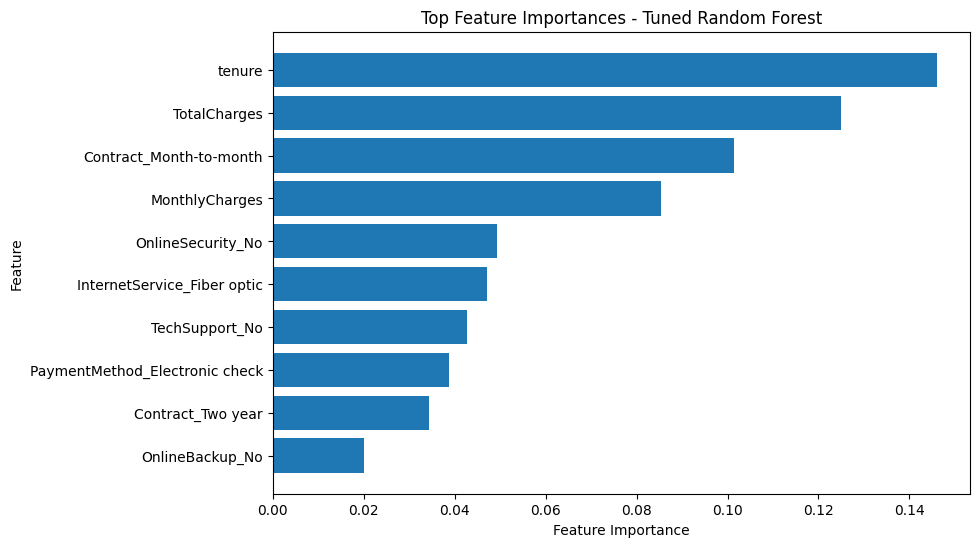

Top 5 features: ['tenure', 'TotalCharges', 'Contract_Month-to-month', 'MonthlyCharges', 'OnlineSecurity_No']


In [14]:
# Feature importances from the tuned Random Forest (the final model, see Section 9).
importances_rf = pd.Series(
    tuned_rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 features:")
display(importances_rf.head(10).to_frame("importance"))

top_features_plot = importances_rf.head(10).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_features_plot.index, top_features_plot.values)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances - Tuned Random Forest")
plt.show()

print("Top 5 features:", list(importances_rf.head(5).index))


**Interpretation:** The top features from the tuned Random Forest are `tenure`, `TotalCharges`, `Contract_Month-to-month`, `MonthlyCharges`, and `OnlineSecurity_No`. This mostly agrees with the Lab 3 Decision Tree, which also relied heavily on `Contract_Month-to-month`, `TotalCharges`, and `tenure` for its splits, even though the exact ranking differs — the Random Forest spreads importance across more features because it averages over many trees, while the single Decision Tree leaned very heavily on the contract-type split. Both models point to the same overall story: customers with short tenure, low total charges, and month-to-month contracts are the ones most associated with churn, which lines up with the churn patterns explored in the Lab 2 EDA. Feature importance only shows how much a feature was used by the model, so this should be read as an association rather than proof that these factors directly cause churn.

## 9. Final Model Selection

**Final model: tuned Random Forest.** Based on the table in Section 7, the tuned Random Forest has the best F1-score of the three models and a precision/recall balance that is at least as good as the default Random Forest, while the 5-fold cross-validation in Section 5 shows the Random Forest's performance is reasonably stable across folds rather than being the result of one favorable split. The Decision Tree remains a reasonable, simpler alternative with competitive recall, but the tuned Random Forest is chosen as the final model because it gives the best overall balance of the four metrics on the held-out test set, not just the highest training or CV score.

## 10. Kaggle Prediction/Submission

`clean_churn.csv` does not include a `customerID` column (this was already confirmed in Lab 3), so the row index of the held-out test set is used as the customer identifier for the submission file.

In [15]:
final_model = tuned_rf_model
final_test_predictions = final_model.predict(X_test)

submission_df = pd.DataFrame({
    "CustomerID": X_test.index,
    "Predicted_Churn": pd.Series(final_test_predictions, index=X_test.index).map({0: "No", 1: "Yes"})
})

submission_df.to_csv("submission.csv", index=False)

print("submission.csv saved. Shape:", submission_df.shape)
submission_df.head()


submission.csv saved. Shape: (1407, 2)


,CustomerID,Predicted_Churn
971,971,No
618,618,Yes
4282,4282,No
3715,3715,No
4525,4525,No


**Interpretation:** The submission file contains one row per test-set customer, with a `CustomerID` (the row index from the cleaned dataset, since no original ID column was available) and the final model's predicted `Churn` label. This mirrors the shape expected by a Kaggle-style classification submission.

## 11. Conclusion

This lab extended the Lab 3 Decision Tree baseline by training a Random Forest on the same Telco Customer Churn data and split, then comparing the two models using accuracy, precision, recall, F1-score, cross-validation, and hyperparameter tuning. The default Random Forest performed close to the Decision Tree, and tuning it with a small grid search gave a modest further improvement in F1-score on the test set, so the tuned Random Forest was selected as the final model. Feature importance from the final model showed that tenure, total charges, and month-to-month contracts are the strongest signals of churn, which is consistent with the Lab 3 Decision Tree's own top features. The main limitation is that the improvement over the simple Decision Tree is fairly modest, and the model still misses a noticeable share of actual churners because of the class imbalance in the data. Cross-validation showed that the results are reasonably stable across folds rather than depending on one lucky split, which adds some confidence to this conclusion. Overall, the tuned Random Forest is a slightly stronger and more reliable churn classifier than the single Decision Tree, but there is still room to improve recall on the minority churn class.

**Next steps (not implemented here):** Given more time, it would be worth trying other algorithms such as Gradient Boosting or Logistic Regression for comparison, exploring class-imbalance techniques like class weighting or SMOTE to improve recall on the churn class, and running a larger hyperparameter search with more folds or a wider grid to see if performance improves further.